In this notebook we will cover some of the basic strategies to compile valid circuits when the qubit connectivity is limited.

### Packages

Before using this notebook make sure you install in your Python environment the following packages

- qiskit (versions 2.1.2 and 2.3.0 have been tested and work fine)
- qiskit-aer (version 0.17.2)
- pylatexenc

If you have trouble installing the packages on your machine, you can try to run this on [Colab](https://colab.research.google.com). In this case you will need to run the following cell to proceed with the installation

In [1]:
%pip install uv --quiet
!uv pip install --quiet \
    "qiskit==2.1.2" \
    "qiskit-aer==0.17.2"\
    pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 62.4 MB/s eta 0:00:00


### Accessing real backends
During the school we will provide access to both the Lagrange machine and IBMQ. If you already have access, you could directly use them by first loading your credentials with the following snippet (uncomment it first)

In [ ]:
## IBMQ
#from qiskit_ibm_runtime import QiskitRuntimeService
## IQM Lagrange
#from iqm.qiskit_iqm import IQMProvider

### loading saved credentials
#ibmq_service = QiskitRuntimeService()
### loading access to Lagrange
#!lagrangeclient

And then loading two backends, one for Lagrange  (uncomment it first)

In [ ]:
#import os
### get the backend for Lagrange
#os.environ["IQM_TOKENS_FILE"] = "./tokens.json"
#iqm_url = "https://spark.quantum.linksfoundation.com/"
#quantum_computer = "default"

#lagrange_provider = IQMProvider(iqm_url,quantum_computer=quantum_computer)
#lagrange_backend = lagrange_provider.get_backend()

and another for one of the IBMQ device, here we will use `ibm_fez`

In [ ]:
#backend_fez = ibmq_service.backend('ibm_fez')

For the remainder of the notebook we will not assume you already have access to these backends and instead create a couple of FakeBackends to work with instead. You can of course play with the actual ones by changing the backend variable.

### Inizialize a backend with the specified connectivity

Here we will generate a local backend with a connectivity similar to to one of Lagrange

In [2]:
from qiskit.providers.fake_provider import GenericBackendV2
# Generate a 5-qubit simulated backend
fake_lagrange_backend = GenericBackendV2(
    num_qubits=5,
    coupling_map=[(0, 2), (1, 2), (2, 3), (2, 4)] ## this is the same coupling map as Lagrange
)

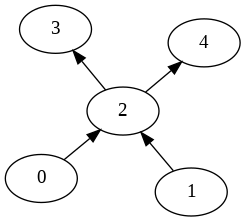

In [3]:
## we can plot the coupling map directing using the 'draw' method
fake_lagrange_backend.coupling_map.draw()

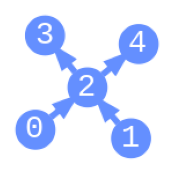

In [4]:
from qiskit.visualization import plot_coupling_map
## or using a fancier plotting tool available in qiskit
plot_coupling_map(
    num_qubits = fake_lagrange_backend.coupling_map.size(),
    qubit_coordinates = None,
    coupling_map=fake_lagrange_backend.coupling_map.get_edges(),
    plot_directed=True,
    figsize = (2,2)
)

The IBMQ devices we will have access to have instead a 'heavy hex' connectivity. You can have a look at the coupling map, and lots of additional information, from the device information page on the IBMQ platform (for instance [here](https://quantum.cloud.ibm.com/computers?system=ibm_fez)). For example, two tiles of the heavy hex topology will look like the following

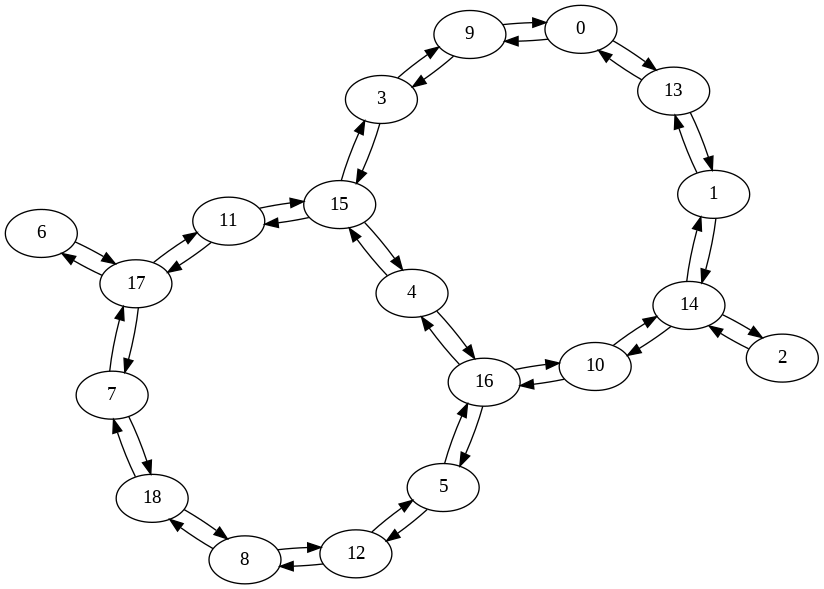

In [5]:
from qiskit.transpiler import CouplingMap
# here we just generate and plot the coupling map.
CouplingMap.from_heavy_hex(3).draw()
## If you want to initialize a backend with this coupling map you can use instead the following code
#
#cm = CouplingMap.from_heavy_hex(3)
## Generate a simulated backend from a given coupling map
#fake_ibmq_backend = GenericBackendV2(
#    num_qubits=cm.size(),
#    coupling_map=cm
#)

### Impact of connectivity

The connectivity maps shown above tell us two things:
- which qubits are connected to which qubits
- wheter the connection is bi-directional or one-directional

The IBM devices are bi-directional by construction as they effectively implement a $CZ$ gate between pairs of connected qubits while Lagrange seems to be one-directional. This would have been the case if the hardware gates where $CNOT$ and we could only do $CNOT(0,2)$ but not $CNOT(2,0)$. This was typical of early generations transmon devices and the standard technique to avoid the problem was to use the following identity

$$CNOT(q_0,q_1) = H(q_0)H(q_1)CNOT(q_1,q_0)H(q_0)H(q_1)$$

Using Hadamard gates on both qubits before and after a $CNOT$ we can invert its direction (see Exercise 2 on the `Basic_Gates_and_Pauli_exponentials` notebook).

Fortunately we do not have to worry about this in this case since Lagrange actually also implements $CZ$ gates and the connections are therefore bi-directional (even if the coupling map would suggest otherwise).

If we want to know the available instructions on a given backend we can use the following

In [6]:
fake_lagrange_backend.instructions

[(Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (0, 2)),
 (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (1, 2)),
 (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (2, 3)),
 (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (2, 4)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (0,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (1,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (2,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (3,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (4,)),
 (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
  (0,)),
 (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
  (1,)),
 (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
  (2,)),
 (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
  (3,)),


As you can see the local backend we initialized does not have $CZ$ operations but uses $CX$, which we called $CNOT$ before, instead. We can of course make a better simulated Lagrange backend by using 'cz' gates instead as follows

In [7]:
# Generate a 5-qubit simulated backend
better_fake_lagrange_backend = GenericBackendV2(
    num_qubits=5,
    coupling_map=[(0, 2), (1, 2), (2, 3), (2, 4)], ## this is the same coupling map as Lagrange
    basis_gates=["id", "rz", "sx", "x", "cz"]
)

### Example 1: Bell pair preparation

Imagine we want to generate a Bell state $\rvert\Phi\rangle=(\rvert 00\rangle+\rvert11\rangle)/\sqrt{2}$ on the two Lagrange backends we built. There are at least two ways of doing this

In [8]:
from qiskit import transpile
from qiskit import QuantumCircuit

## this is the first version
circuitA = QuantumCircuit(2)
circuitA.h(0)
circuitA.cx(0, 1)

print(circuitA.draw('text'))

## and this is the second
circuitB = QuantumCircuit(2)
circuitB.h(1)
circuitB.cx(1, 0)
print(circuitB.draw('text'))

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
          ┌───┐
q_0: ─────┤ X ├
     ┌───┐└─┬─┘
q_1: ┤ H ├──■──
     └───┘     


Let's try now to compile the circuits for Lagrange.
If we don't specify the qubits we want, and we disable optimizations, the compiled circuit might use a third qubit to connect them. In this case qiskit tried to use qubit $0$ for `q_0` and qubit $1$ form `q_1` but these are not directly connected (see coupling map).

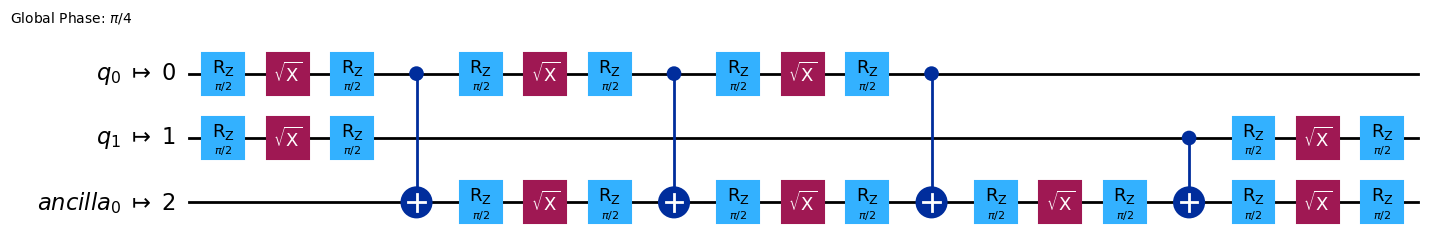

In [9]:
from qiskit import transpile

transpiled_circuitA = transpile(circuitA, backend=fake_lagrange_backend,optimization_level=0)
transpiled_circuitA.draw('mpl')

If we don't care about what qubits are actually being used, enabling compiler optimizations (enabled by default) solves this

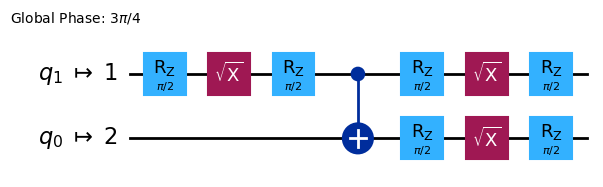

In [10]:
transpiled_circuitA = transpile(circuitA, backend=fake_lagrange_backend,optimization_level=1)
transpiled_circuitA.draw('mpl')

Since we are not picking qubits, compiling `circuitB` in the same way results in the same circuit

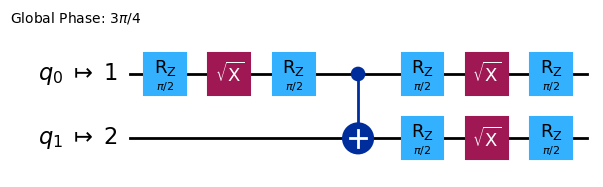

In [11]:
transpiled_circuitB = transpile(circuitB, backend=fake_lagrange_backend,optimization_level=1)
transpiled_circuitB.draw('mpl')

Most times we actually want to tell the compiler which qubits we want to use. To do so we can use the `initial_layout` option of the transpiler

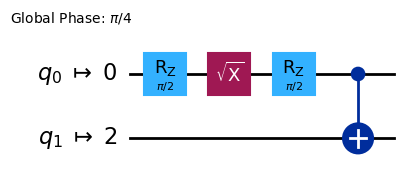

In [12]:
transpiled_circuitA = transpile(
    circuitA,
    backend=fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[0,2]
)
transpiled_circuitA.draw('mpl')

Note how, even with `optimization_level=0`, thinking about what we want to do can lead to the best circuit implementation so far. Trying to compile now `circuit_B` still between qubit $0$ and qubit $2$ requires additional single qubit gates to reverse the CNOT

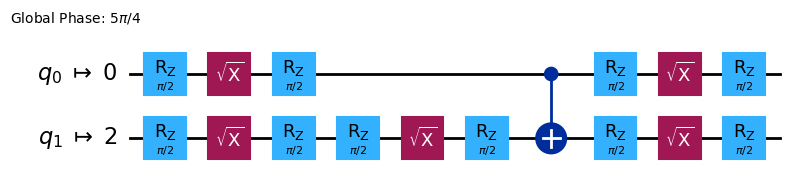

In [13]:
transpiled_circuitB = transpile(
    circuitB,
    backend=fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[0,2]
)
transpiled_circuitB.draw('mpl')

Of course when the basis gates ar $CZ$ instead this won't matter

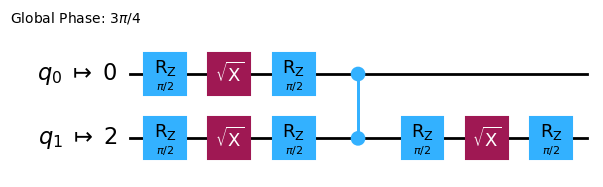

In [14]:
transpiled_circuitA = transpile(
    circuitA,
    backend=better_fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[0,2]
)
transpiled_circuitA.draw('mpl')

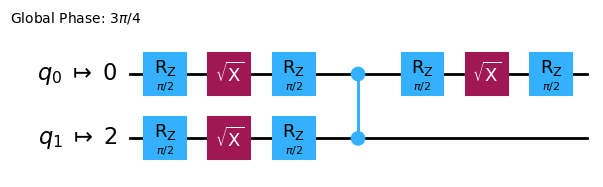

In [15]:
transpiled_circuitB = transpile(
    circuitB,
    backend=better_fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[0,2]
)
transpiled_circuitB.draw('mpl')

In general it is safe to set `optimization_level=2` (enabled by default) if you specify which qubits you want using an explicit `initial_layout` since what the compiler does is only to try and minimize the number of gates being used

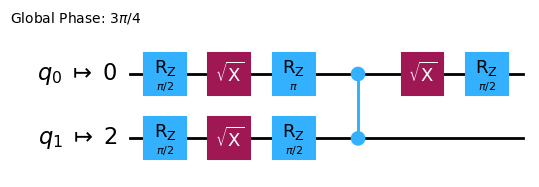

In [16]:
transpiled_circuitB_opt = transpile(
    circuitB,
    backend=better_fake_lagrange_backend,
    optimization_level=2,
    initial_layout=[0,2]
)
transpiled_circuitB_opt.draw('mpl')

### Example 2: GHZ preparation

Preparing Bell states is rather easy since we always will have at least two qubits connected in the right way. To make things a bit more challenging we will now try to prepare instead some multi-qubit GHZ states. These are defined as follows

$$\rvert GHZ_3\rangle=\frac{1}{\sqrt{2}}\left(\rvert 000\rangle+\rvert 111\rangle\right)$$
$$\rvert GHZ_4\rangle=\frac{1}{\sqrt{2}}\left(\rvert 0000\rangle+\rvert 1111\rangle\right)$$
$$\rvert GHZ_5\rangle=\frac{1}{\sqrt{2}}\left(\rvert 00000\rangle+\rvert 11111\rangle\right)$$

Of course this can be generalized to any number of qubits but since we have only $5$ on Lagrange we'll stop there.

The idealized circuit to prepare $\rvert GHZ_3\rangle$ is for instance

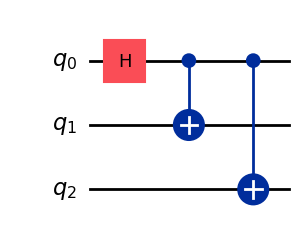

In [17]:
circuitA = QuantumCircuit(3)
circuitA.h(0)
circuitA.cx(0, 1)
circuitA.cx(0, 2)
circuitA.draw('mpl')

A simple way to make sure we can implement this is to use qubit $2$ as the control, for instance as follows

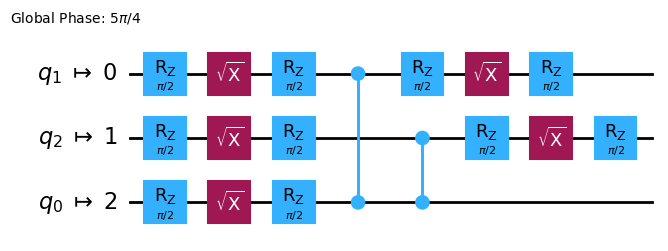

In [18]:
transpiled_circuitA = transpile(
    circuitA,
    backend=better_fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[2,0,1]
)
transpiled_circuitA.draw('mpl')

Try to convince yourself that this strategy allows to prepare all three $GHZ$ states defined above without any impact from the limited connectivity. The pattern of what we want to do is also simple enough that  `optimization_level=2` can figure this out on its own (try it).

### Example 3: GHZ state preparation for fixed layout

As we saw above, exploiting the freedom to choose what physical qubits to use allows us to make a careful choice to reduce the impact of limited connectivity. Sometimes however the choice of layout is dictated by other considerations like, for instance, additional gates we want to do after state preparation. In these cases a simple way to tackle the problem is to swap the location of qubits as we go. To do this we can use the aptly named $SWAP$ gate defined as

$$SWAP = \begin{pmatrix}
1&0&0&0\\
0&0&1&0\\
0&1&0&0\\
0&0&0&1\\
\end{pmatrix}$$

This operation can be implemented in a straghtforward way using $CNOT$ gates as

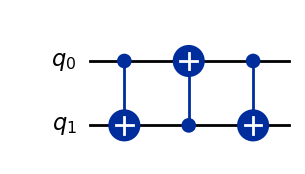

In [19]:
swap_circuitA=QuantumCircuit(2)
swap_circuitA.cx(0,1)
swap_circuitA.cx(1,0)
swap_circuitA.cx(0,1)
swap_circuitA.draw('mpl')

or equivalently (why?) as the following

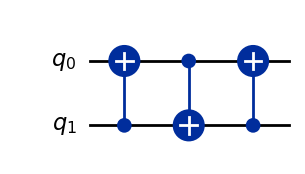

In [20]:
swap_circuitB=QuantumCircuit(2)
swap_circuitB.cx(1,0)
swap_circuitB.cx(0,1)
swap_circuitB.cx(1,0)
swap_circuitB.draw('mpl')

Using $SWAP$ gates we can then always make a valid circuit. For instance, the circuit used above for $\rvert GHZ_3\rangle$ can be implemented on a layout $[0,1,2]$ using two $SWAP$ gates to temporarily move qubit $0$ at the location of qubit $2$, perform the $CNOT(0,1)$ as a physical $CNOT(2,1)$ and swap back to restore the ordering

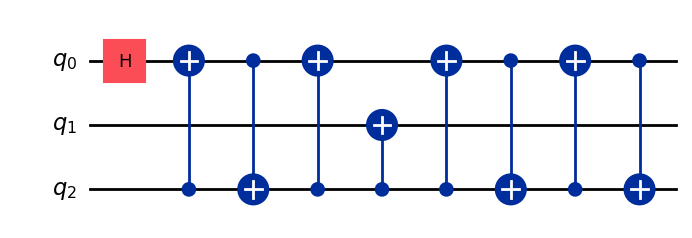

In [21]:
circuitA_full_SWAP = QuantumCircuit(3)
circuitA_full_SWAP.h(0)
## this is the operation we can't do
#circuitA_full_SWAP.cx(0, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
## cx(0, 1) now is cx(2, 1)
circuitA_full_SWAP.cx(2, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.draw('mpl')

This blind $SWAP$ insertion does make the circuit executable but it is essentially never the best thing to do.

A first simple optimization comes from realizing that we have two inequivalent ways to express a $SWAP$ and we should think which one we might prefer first. If you look at the end of the circuit you'll see we have an additional $CNOT(0,2)$ which could be cancelled if we do the following instead

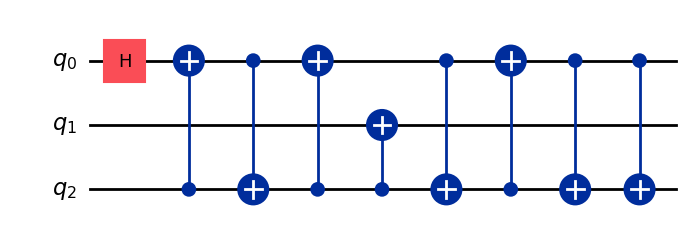

In [22]:
circuitA_full_SWAP = QuantumCircuit(3)
circuitA_full_SWAP.h(0)
## this is the operation we can't do
#circuitA_full_SWAP.cx(0, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
## cx(0, 1) now is cx(2, 1)
circuitA_full_SWAP.cx(2, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.draw('mpl')

which is then equivalent to

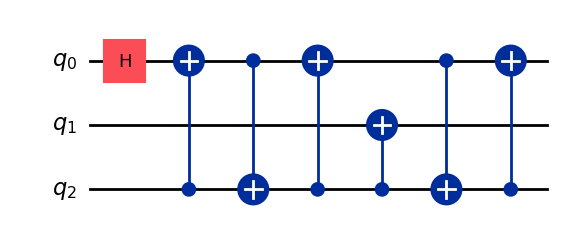

In [23]:
circuitA_full_SWAP = QuantumCircuit(3)
circuitA_full_SWAP.h(0)
## this is the operation we can't do
#circuitA_full_SWAP.cx(0, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
## cx(0, 1) now is cx(2, 1)
circuitA_full_SWAP.cx(2, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.draw('mpl')

But since this is state preparation and all qubits start in $\rvert0\rangle$, the first $CNOT$ to the left actually acts as an identity so we could use the following instead

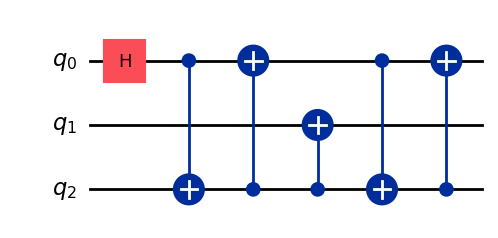

In [25]:
circuitA_full_SWAP = QuantumCircuit(3)
circuitA_full_SWAP.h(0)
## this is the operation we can't do
#circuitA_full_SWAP.cx(0, 1)
## swap 0 <-> 2
#circuitA_full_SWAP.cx(2, 0)# not needed if this is at the beginning
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
## cx(0, 1) now is cx(2, 1)
circuitA_full_SWAP.cx(2, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.draw('mpl')

**NOTE** this last optimization assumed we know the state this unitary will be applied to. For state preparation this is of course fine but try to keep this in mind if you are trying to optimize circuits where this might not be the case.

If we now transpile this we get exactly $5$ $CZ$ gates as expected

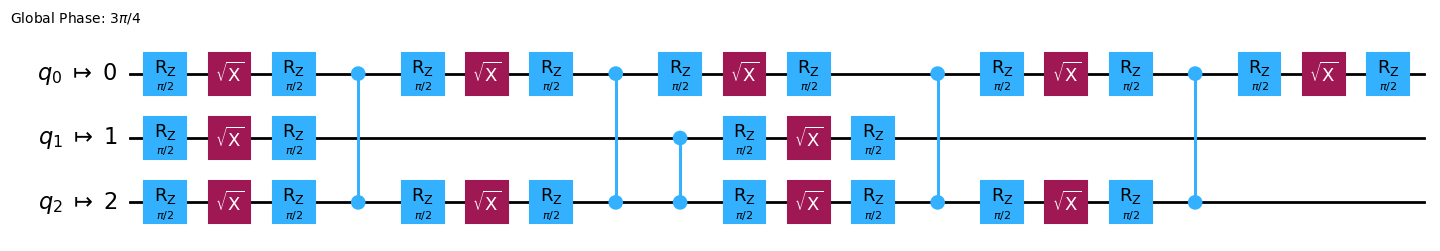

In [26]:
transpiledA_full_SWAP = transpile(
    circuitA_full_SWAP,
    backend=better_fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[0,1,2]
)
transpiledA_full_SWAP.draw('mpl')

Further optimization only reduces the number of $R_Z$ gates (which are "free" anyway)

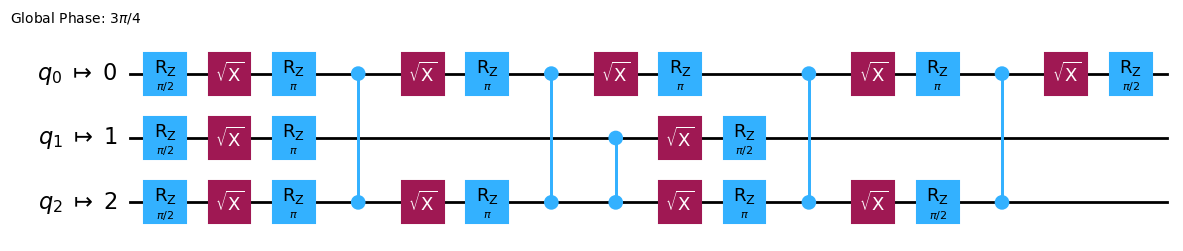

In [27]:
transpiledA_full_SWAP = transpile(
    circuitA_full_SWAP,
    backend=better_fake_lagrange_backend,
    optimization_level=2,
    initial_layout=[0,1,2]
)
transpiledA_full_SWAP.draw('mpl')

The job of the transpiler is to give us valid circuits, let's see what it does if we don't help it

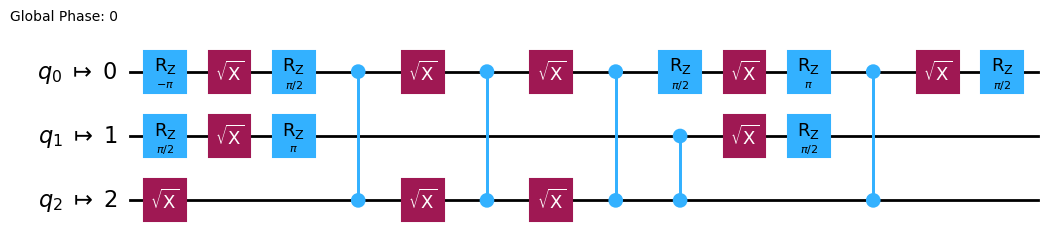

In [28]:
transpiledA_auto_transpile = transpile(
    circuitA,
    backend=better_fake_lagrange_backend,
    optimization_level=2,
    initial_layout=[0,1,2]
)
transpiledA_auto_transpile.draw('mpl')

This circuit still has $5$ $CZ$ gates but looks different. What the transpiler did here was instead to implement this circuit

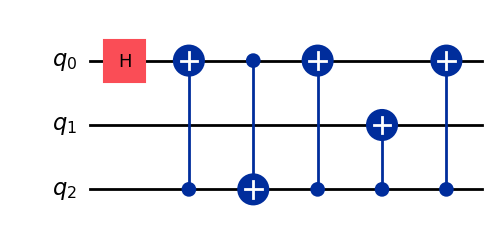

In [29]:
circuitA_full_SWAP = QuantumCircuit(3)
circuitA_full_SWAP.h(0)
## this is the operation we can't do
#circuitA_full_SWAP.cx(0, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
## cx(0, 1) now is cx(2, 1)
circuitA_full_SWAP.cx(2, 1)
## now we don't swap back but simply use
## cx(0, 2) now is cx(2, 0)
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.draw('mpl')

In other words, the transpiler only applied the first $SWAP$ to send $0$ into $2$ but then never moved it back. The last $CNOT$ was then inverted to account for the new location of $0$ and $2$. Why is this correct? Well, the map between the three qubit $[q_0,q_1,q_2]$ and the physical qubits is somewhat arbitrary and we can allow for it to change as we progress with a circuit. The important thing is that at every stage we are able to keep track of where the original qubits are located and perform operations accordingly.

For instance, in the circuit above, after the third $CNOT$ the qubit ordering has been changed to $[q_2,q_1,q_0]$ and never changed back (as we did above with the second $SWAP$ gate). Unfortunately the transpiler does not tell us this explicitly but internally the qubit assignment has been changed. To see this, look what happens if we try to apply an $X$ gate to qubit $q_2$ after this circuit

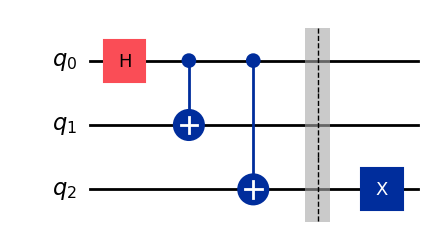

In [30]:
circuitA_plusX2 = QuantumCircuit(3)
circuitA_plusX2.h(0)
circuitA_plusX2.cx(0, 1)
circuitA_plusX2.cx(0, 2)
# here we are adding a barrier to avoid moving the next gate back
circuitA_plusX2.barrier()
circuitA_plusX2.x(2)
circuitA_plusX2.draw('mpl')

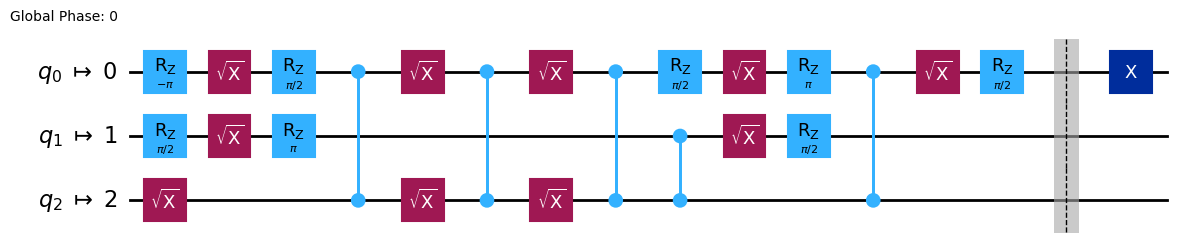

In [31]:
transpiledA_auto_transpile = transpile(
    circuitA_plusX2,
    backend=better_fake_lagrange_backend,
    optimization_level=2,
    initial_layout=[0,1,2]
)
transpiledA_auto_transpile.draw('mpl')

See where the $X$ gate is at the end? The transpiler has correctly stored the location of $q_2$ at the end of the circuit.

**NOTE**: never manipulate a transpiled circuit since you might get wrong results as shown below

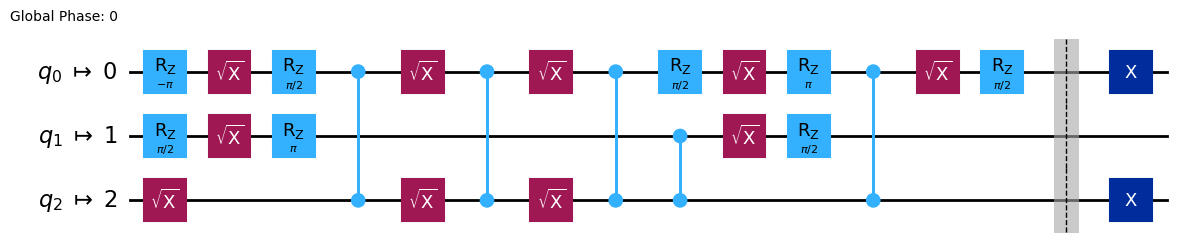

In [32]:
transpiledA_auto_transpile.x(2)
transpiledA_auto_transpile.draw('mpl')

# Exercise 1

Imagine we want to use the following three circuits for preparing the $GHZ$ states

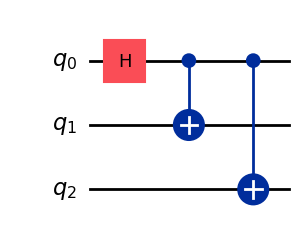

In [33]:
circuit_ghz3 = QuantumCircuit(3)
circuit_ghz3.h(0)
circuit_ghz3.cx(0, 1)
circuit_ghz3.cx(0, 2)
circuit_ghz3.draw('mpl')

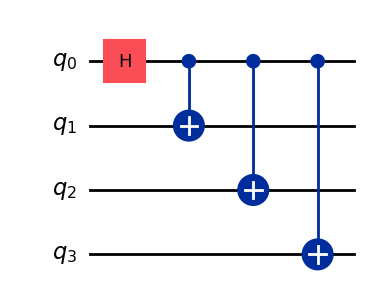

In [34]:
circuit_ghz4 = QuantumCircuit(4)
circuit_ghz4.h(0)
circuit_ghz4.cx(0, 1)
circuit_ghz4.cx(0, 2)
circuit_ghz4.cx(0, 3)
circuit_ghz4.draw('mpl')

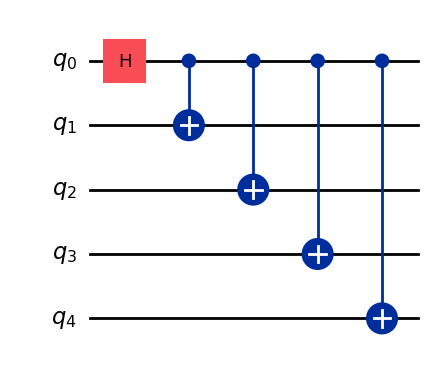

In [35]:
circuit_ghz5 = QuantumCircuit(5)
circuit_ghz5.h(0)
circuit_ghz5.cx(0, 1)
circuit_ghz5.cx(0, 2)
circuit_ghz5.cx(0, 3)
circuit_ghz5.cx(0, 4)
circuit_ghz5.draw('mpl')

We will take respectively the layouts $[0,1,2]$, $[0,1,2,3]$ and $[0,1,2,3,4]$ on the Lagrange connectivity. If we let the transpiler do its thing we get circuits with $5$, $6$ and $7$ $CZ$ gates. This is because once we move $0$ into $2$ everything becomes simpler.

- can you beat the transpiler **without** using the fact that we are starting in the all $\rvert 0\rangle$ state?
- how much more can you beat it if you do assume the initial state is all qubits in $\rvert0\rangle$?

To manipulate with ease circuits with many $CNOT$ gates you might want to have a look for instance at [this paper](https://arxiv.org/abs/1110.2998).

Once you have done that, try to do the same optimizations for $GHZ$ preparation on a line of qubits with nearest-neighbor connectivity only. If you want to check what the transpiler would have done in that case you can get a backend with that connectivity using the following

In [36]:
# Generate a simulated backend from a given coupling map
fake_line_backend = GenericBackendV2(
    num_qubits=5,
    coupling_map=CouplingMap.from_line(5)
)

# Exercise 2

Imagine we want to implement the follwoing unitary transformation

$$U(\theta) = \exp\left(-i \theta Z_0Z_1Z_2\right)\exp\left(-i \theta Z_0Z_1\right)\exp\left(-i \theta Z_0Z_1Z_3\right)\exp\left(-i \theta Z_0Z_1Z_2Z_3\right)$$

on a device with Lagrange connectivity. With all-to-all connectivity and a naive compilation following the strategy for Pauli exponentiation on the other notebook this would cost $16$ CNOT gates and $4$ $R_Z$ gates.

With a bit of thought, and without worrying about connectivity, you can easily see that this can be done with only $8$ $CNOT$. In fact even the transpiler is able to figure out a version with this many $CNOT$ gates.

- try to beat the transpiler without worrying about qubit connectivity. What's you best $CNOT$ count?

**HINT**: keep in mind that the $4$ unitaries written above all commute with each other...

If we now restrict the connectivity to the one of Lagrange, and we set as initial layout $[0,2,1,3]$ the transpiler produces a circuit with $14$ CNOT gates. We can do much better than that

- how many **valid** $CNOT$ gates do you need to compile the $U(\theta)$ with limited connectivity?

**HINT**: for circuits like this it is convenient to use as target the qubit connected to everyone. If you do this, in a way that also satisfies the connectivity, you can find an essentially optimal implementation that is not impacted by the restricted connectivity.

<details>
  <summary> ADDITIONAL HINT: Try not to use this until you have your best circuit</summary>
  Only $6$ CNOT gates are required with either connectivity
</details>

### BONUS

If all of this seemed way to easy, but you still want to practice your ability to optimize circuits, try to have a look at the circuit implementations you find in

- Appendix F on [this paper](https://arxiv.org/abs/2009.13485)
- Appendix B of [this paper](https://arxiv.org/abs/2111.02982)
- Appendix C on [this paper](https://arxiv.org/pdf/2503.00607)

All of these are examples of hand-crafted circuit layouts optimized to minimize the impact of limited connectivity. Try to start from the original circuits and see how your optimized circuit compares to ours. If yours is better, please do let us know